# Optimisation de LightGBM et du seuil métier

Ce notebook optimise progressivement LightGBM, puis choisit un seuil de décision qui minimise le coût métier `10 × FN + FP`.

## Chargement et séparation des données

In [10]:
# ---------- Bibliothèques ----------
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, f1_score, recall_score, roc_auc_score
from sklearn.model_selection import ParameterGrid, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline

# ---------- Configuration des données ----------
DATA_PATH = Path("../data/processed/application_train_final_encoded.csv")
ID_COLUMN = "SK_ID_CURR"
TARGET_COLUMN = "TARGET"
RANDOM_STATE = 42

if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Fichier introuvable : {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)
required_columns = {ID_COLUMN, TARGET_COLUMN}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Colonnes obligatoires absentes : {sorted(missing_columns)}")

X = df.drop(columns=[ID_COLUMN, TARGET_COLUMN])
y = df[TARGET_COLUMN]

# 80 % servent à l'entraînement et à la validation croisée ; 20 % restent intouchés pour l'évaluation finale.
X_train, X_final, y_train, y_final = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

SCALE_POS_WEIGHT = (y_train == 0).sum() / (y_train == 1).sum()

print(f"Entraînement : {len(X_train):,} lignes")
print(f"Évaluation finale : {len(X_final):,} lignes")
print(f"Poids de la classe 1 : {SCALE_POS_WEIGHT:.2f}")

Entraînement : 246,008 lignes
Évaluation finale : 61,502 lignes
Poids de la classe 1 : 11.39


## Preprocessing et coût métier

L'imputation médiane est apprise uniquement pendant l'entraînement. Le coût métier pénalise un faux négatif dix fois plus qu'un faux positif.

In [11]:
# ---------- Pipeline LightGBM ----------
def create_lightgbm_pipeline(model_params):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("classifier", LGBMClassifier(**model_params)),
    ])


# ---------- Coût métier ----------
FN_COST = 10
FP_COST = 1
THRESHOLDS = [value / 100 for value in range(10, 91, 5)]

"""Cette fonction calcule le coût métier associé aux prédictions du modèle.
Elle récupère le nombre de faux négatifs et de faux positifs grâce à la matrice de confusion, 
puis applique la formule 10 × FN + 1 × FP. 
Plus ce coût est faible, plus les décisions prises par le modèle sont intéressantes du point de vue métier."""

def business_cost(y_true, y_pred):
    _, fp, fn, _ = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return FN_COST * fn + FP_COST * fp


# ---------- Métriques d'évaluation ----------
def evaluate_predictions(y_true, y_pred, y_score):
    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()
    return {
        "roc_auc": roc_auc_score(y_true, y_score),
        "recall": recall_score(y_true, y_pred, pos_label=1),
        "f1_score": f1_score(y_true, y_pred, pos_label=1),
        "fn": int(fn),
        "fp": int(fp),
        "business_cost": int(FN_COST * fn + FP_COST * fp),
    }

## Optimisation des hyperparamètres

Chaque combinaison est testée explicitement sur cinq folds stratifiés. Pour chaque seuil, les coûts et recalls sont moyennés sur les folds. Les paramètres sont classés selon leur meilleur coût métier moyen.

In [12]:
# ---------- Configuration de la recherche ----------
GRID_MODEL_PARAMS = {
    "boosting_type": "gbdt",
    "objective": "binary",
    "random_state": RANDOM_STATE,
    "n_jobs": 1,
    "verbosity": -1,
}

PARAM_GRID = {
    "classifier__n_estimators": [100, 300],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__num_leaves": [15, 31],
}

CV = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

threshold_cv_results = []

# ---------- Test de chaque combinaison d'hyperparamètres ----------
for combination_id, params in enumerate(ParameterGrid(PARAM_GRID), start=1):
    model_params = {
        name.replace("classifier__", ""): value
        for name, value in params.items()
    }

    costs_by_threshold = {threshold: [] for threshold in THRESHOLDS}
    recalls_by_threshold = {threshold: [] for threshold in THRESHOLDS}
    roc_auc_scores = []

    # ---------- Validation croisée ----------
    for train_index, validation_index in CV.split(X_train, y_train):
        X_fold_train = X_train.iloc[train_index]
        X_fold_validation = X_train.iloc[validation_index]
        y_fold_train = y_train.iloc[train_index]
        y_fold_validation = y_train.iloc[validation_index]

        scale_pos_weight = (
            (y_fold_train == 0).sum() / (y_fold_train == 1).sum()
        )
        fold_params = {
            **GRID_MODEL_PARAMS,
            **model_params,
            "scale_pos_weight": scale_pos_weight,
        }

        model = create_lightgbm_pipeline(fold_params)
        model.fit(X_fold_train, y_fold_train)
        probabilities = model.predict_proba(X_fold_validation)[:, 1]

        roc_auc_scores.append(
            roc_auc_score(y_fold_validation, probabilities)
        )

        # ---------- Test de tous les seuils ----------
        for threshold in THRESHOLDS:
            predictions = (probabilities >= threshold).astype(int)
            costs_by_threshold[threshold].append(
                business_cost(y_fold_validation, predictions)
            )
            recalls_by_threshold[threshold].append(
                recall_score(
                    y_fold_validation, predictions, pos_label=1, zero_division=0
                )
            )

    # ---------- Moyenne des cinq folds pour chaque seuil ----------
    for threshold in THRESHOLDS:
        costs = pd.Series(costs_by_threshold[threshold])
        recalls = pd.Series(recalls_by_threshold[threshold])
        threshold_cv_results.append({
            "combination_id": combination_id,
            "params": params,
            "threshold": threshold,
            "cv_business_cost_mean": costs.mean(),
            "cv_business_cost_std": costs.std(ddof=0),
            "cv_roc_auc_mean": pd.Series(roc_auc_scores).mean(),
            "cv_recall_mean": recalls.mean(),
        })

# ---------- Résultats complets ----------
threshold_cv_results = pd.DataFrame(threshold_cv_results)
display(threshold_cv_results.sort_values("cv_business_cost_mean"))

# ---------- Meilleur seuil de chaque combinaison ----------
best_indices = (
    threshold_cv_results
    .groupby("combination_id")["cv_business_cost_mean"]
    .idxmin()
)
grid_results = (
    threshold_cv_results
    .loc[best_indices]
    .sort_values("cv_business_cost_mean")
    .reset_index(drop=True)
)
grid_results["rank_test_business_cost"] = range(1, len(grid_results) + 1)

display(grid_results[[
    "combination_id", "params", "threshold",
    "cv_business_cost_mean", "cv_business_cost_std",
    "cv_roc_auc_mean", "cv_recall_mean",
    "rank_test_business_cost",
]])

# ---------- Meilleure combinaison ----------
best_grid_row = grid_results.iloc[0]
BEST_GRID_PARAMS = best_grid_row["params"]
BEST_CV_THRESHOLD = float(best_grid_row["threshold"])
BEST_CV_BUSINESS_COST = float(best_grid_row["cv_business_cost_mean"])

print("Meilleurs paramètres :", BEST_GRID_PARAMS)
print(f"Meilleur seuil pendant la CV : {BEST_CV_THRESHOLD:.2f}")
print(f"Meilleur coût métier CV : {BEST_CV_BUSINESS_COST:,.0f}")

,combination_id,params,threshold,cv_business_cost_mean,cv_business_cost_std,cv_roc_auc_mean,cv_recall_mean
59,4,"{'classifier__learning_rate': 0.05, 'classifie...",0.50,24523.8,331.153982,0.779480,0.686037
43,3,"{'classifier__learning_rate': 0.05, 'classifie...",0.55,24616.2,315.894539,0.778852,0.637998
42,3,"{'classifier__learning_rate': 0.05, 'classifie...",0.50,24669.6,307.741190,0.778852,0.703460
110,7,"{'classifier__learning_rate': 0.1, 'classifier...",0.50,24673.0,301.319764,0.777383,0.684476
93,6,"{'classifier__learning_rate': 0.1, 'classifier...",0.50,24728.6,389.396764,0.777485,0.695957
...,...,...,...,...,...,...,...
1,1,"{'classifier__learning_rate': 0.05, 'classifie...",0.15,42378.0,88.843683,0.769632,0.992749
34,3,"{'classifier__learning_rate': 0.05, 'classifie...",0.10,42761.6,58.445188,0.778852,0.994813
68,5,"{'classifier__learning_rate': 0.1, 'classifier...",0.10,43268.8,81.959502,0.776124,0.996123
17,2,"{'classifier__learning_rate': 0.05, 'classifie...",0.10,43837.2,125.878354,0.774142,0.997331


,combination_id,params,threshold,cv_business_cost_mean,cv_business_cost_std,cv_roc_auc_mean,cv_recall_mean,rank_test_business_cost
0,4,"{'classifier__learning_rate': 0.05, 'classifie...",0.50,24523.8,331.153982,0.779480,0.686037,1
1,3,"{'classifier__learning_rate': 0.05, 'classifie...",0.55,24616.2,315.894539,0.778852,0.637998,2
2,7,"{'classifier__learning_rate': 0.1, 'classifier...",0.50,24673.0,301.319764,0.777383,0.684476,3
3,6,"{'classifier__learning_rate': 0.1, 'classifier...",0.50,24728.6,389.396764,0.777485,0.695957,4
4,5,"{'classifier__learning_rate': 0.1, 'classifier...",0.55,24803.2,267.597010,0.776124,0.640113,5
5,8,"{'classifier__learning_rate': 0.1, 'classifier...",0.45,24876.0,249.919187,0.774658,0.705977,6
6,2,"{'classifier__learning_rate': 0.05, 'classifie...",0.50,25001.4,327.101574,0.774142,0.703460,7
7,1,"{'classifier__learning_rate': 0.05, 'classifie...",0.50,25287.2,418.038946,0.769632,0.706481,8


Meilleurs paramètres : {'classifier__learning_rate': 0.05, 'classifier__n_estimators': 300, 'classifier__num_leaves': 31}
Meilleur seuil pendant la CV : 0.50
Meilleur coût métier CV : 24,524


## Suivi MLflow des combinaisons

Chaque combinaison produit un seul run contenant les résultats moyens des cinq folds. Aucun run individuel n'est créé pour un fold.

In [13]:
# ---------- Un run MLflow par combinaison ----------
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("credit_scoring")

for run_number, (_, result) in enumerate(grid_results.iterrows(), start=1):
    model_params = {
        name.replace("classifier__", ""): value
        for name, value in result["params"].items()
    }

    with mlflow.start_run(
        run_name=f"lightgbm_search_rank_{run_number:02d}"
    ):
        mlflow.set_tag("stage", "hyperparameter_search")
        mlflow.log_param("business_cost_rank", run_number)
        mlflow.log_param("combination_id", int(result["combination_id"]))
        mlflow.log_param("cv_best_threshold", result["threshold"])
        mlflow.log_params(model_params)
        mlflow.log_metrics({
            "cv_business_cost_mean": result["cv_business_cost_mean"],
            "cv_business_cost_std": result["cv_business_cost_std"],
            "cv_roc_auc_mean": result["cv_roc_auc_mean"],
            "cv_recall_mean": result["cv_recall_mean"],
        })

## Entraînement du meilleur modèle

In [14]:
# ---------- Reconstruction des meilleurs paramètres ----------
best_model_params = {
    name.replace("classifier__", ""): value
    for name, value in BEST_GRID_PARAMS.items()
}
OPTIMIZED_PARAMS = {
    **GRID_MODEL_PARAMS,
    **best_model_params,
    "scale_pos_weight": SCALE_POS_WEIGHT,
    "n_jobs": -1,
}

optimized_model = create_lightgbm_pipeline(OPTIMIZED_PARAMS)
optimized_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](319,)","['NAME_CONTRACT_TYPE','FLAG_OWN_CAR','FLAG_OWN_REALTY',..., 'PREV_POS_REMAINING_INSTALLMENTS_SUM','PREV_CC_BALANCE_LATEST_SUM', 'PREV_HAS_HISTORY']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,319
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_va

## Optimisation du seuil métier

Le seuil est déjà choisi pendant la validation croisée pour la meilleure combinaison d'hyperparamètres. L'ensemble final reste totalement à l'écart de cette décision.

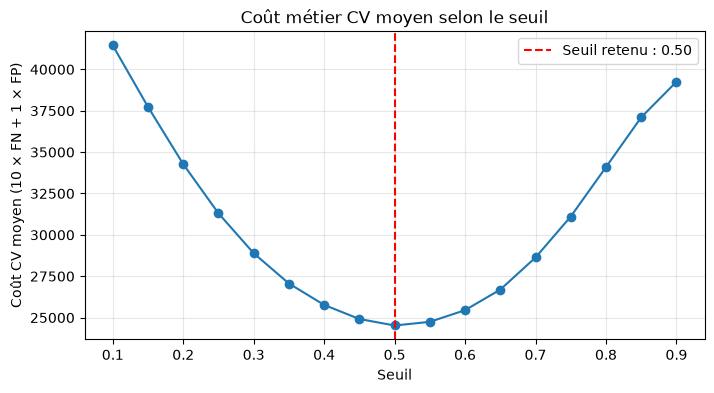

Seuil retenu : 0.50
Coût métier CV moyen : 24,524


In [15]:
# ---------- Courbe CV de la meilleure combinaison ----------
best_combination_id = int(best_grid_row["combination_id"])
threshold_results = (
    threshold_cv_results[
        threshold_cv_results["combination_id"].eq(best_combination_id)
    ]
    [["threshold", "cv_business_cost_mean"]]
    .sort_values("threshold")
)
BEST_THRESHOLD = BEST_CV_THRESHOLD
MIN_THRESHOLD_COST = BEST_CV_BUSINESS_COST

cost_figure, cost_axis = plt.subplots(figsize=(8, 4))
cost_axis.plot(
    threshold_results["threshold"],
    threshold_results["cv_business_cost_mean"],
    marker="o",
)
cost_axis.axvline(BEST_THRESHOLD, color="red", linestyle="--", label=f"Seuil retenu : {BEST_THRESHOLD:.2f}")
cost_axis.set(
    title="Coût métier CV moyen selon le seuil",
    xlabel="Seuil",
    ylabel=f"Coût CV moyen ({FN_COST} × FN + {FP_COST} × FP)",
)
cost_axis.legend()
cost_axis.grid(alpha=0.3)
plt.show()

print(f"Seuil retenu : {BEST_THRESHOLD:.2f}")
print(f"Coût métier CV moyen : {MIN_THRESHOLD_COST:,.0f}")

## Évaluation finale

Le modèle initial et le modèle optimisé sont comparés sur les mêmes clients jamais utilisés par la recherche d'hyperparamètres ni par la sélection du seuil.

In [16]:
# ---------- Modèle LightGBM initial équilibré ----------
BASELINE_PARAMS = {
    "boosting_type": "gbdt",
    "n_estimators": 100,
    "learning_rate": 0.1,
    "num_leaves": 31,
    "max_depth": -1,
    "objective": "binary",
    "scale_pos_weight": SCALE_POS_WEIGHT,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": -1,
}
baseline_model = create_lightgbm_pipeline(BASELINE_PARAMS)
baseline_model.fit(X_train, y_train)

# ---------- Prédictions sur l'ensemble final ----------
baseline_scores = baseline_model.predict_proba(X_final)[:, 1]
optimized_scores = optimized_model.predict_proba(X_final)[:, 1]

baseline_predictions = (baseline_scores >= 0.5).astype(int)
optimized_default_predictions = (optimized_scores >= 0.5).astype(int)
optimized_business_predictions = (optimized_scores >= BEST_THRESHOLD).astype(int)

final_results = pd.DataFrame({
    "baseline_threshold_0.5": evaluate_predictions(
        y_final, baseline_predictions, baseline_scores
    ),
    "optimized_threshold_0.5": evaluate_predictions(
        y_final, optimized_default_predictions, optimized_scores
    ),
    "optimized_business_threshold": evaluate_predictions(
        y_final, optimized_business_predictions, optimized_scores
    ),
}).T
display(final_results)

,roc_auc,recall,f1_score,fn,fp,business_cost
baseline_threshold_0.5,0.775404,0.690836,0.283577,1535.0,15796.0,31146.0
optimized_threshold_0.5,0.778147,0.685398,0.289654,1562.0,15129.0,30749.0
optimized_business_threshold,0.778147,0.685398,0.289654,1562.0,15129.0,30749.0


## Tracking MLflow et conclusion

Cette dernière cellule enregistre uniquement les résultats déjà calculés. Elle ne relance ni la recherche d'hyperparamètres ni l'entraînement.

In [17]:
# ---------- Tracking MLflow manuel ----------
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("credit_scoring")

final_metrics = final_results.loc["optimized_business_threshold"]

with mlflow.start_run(run_name="lightgbm_optimized_final"):
    mlflow.set_tag("stage", "final_evaluation")
    mlflow.set_tag("description", "LightGBM optimisé avec seuil métier")
    mlflow.log_param("model_type", "LGBMClassifier")
    mlflow.log_param("cv_folds", CV.get_n_splits())
    mlflow.log_param("cost_fn", FN_COST)
    mlflow.log_param("cost_fp", FP_COST)
    mlflow.log_param("best_threshold", BEST_THRESHOLD)

    for name, value in best_model_params.items():
        mlflow.log_param(f"best_{name}", value)

    mlflow.log_metric("cv_best_business_cost", MIN_THRESHOLD_COST)
    mlflow.log_metrics(final_metrics.to_dict())

    mlflow.log_figure(cost_figure, "business_cost_by_threshold.png")

print("Run MLflow enregistré : lightgbm_optimized_final")

Run MLflow enregistré : lightgbm_optimized_final


### Lecture des résultats

Le modèle final doit réduire le coût métier et les faux négatifs sans provoquer une hausse disproportionnée des faux positifs. Le ROC AUC vérifie la qualité globale du classement, tandis que le recall et le F1-score complètent l'interprétation du seuil retenu.